# Explore seismic events

### Eartquake data

In [10]:
from pathlib import Path
from obspy import read_events
import obspy
import numpy as np
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [3]:
data_dir = Path("data")

paths = {
    "earthquakes": data_dir / "earthquakes2025.qkml",
    "explosions": data_dir / "explosions2025.qkml",
    "probable_explosions": data_dir / "probable_explosions2025.qkml",
}

catalogs = {}
for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path.resolve()}")
    catalogs[name] = read_events(str(path))
    print(f"{name}: {len(catalogs[name])} events loaded from {path.name}")

earthquakes: 328 events loaded from earthquakes2025.qkml
explosions: 599 events loaded from explosions2025.qkml
probable_explosions: 1455 events loaded from probable_explosions2025.qkml


In [4]:
# Earthquake events catalog
eq_cat = catalogs["earthquakes"]
print(eq_cat)

# Inspect a single event by index
i = 0
event = eq_cat[i]
print(f"\nSingle event (index = {i}):")
print(event)
print("origins:", len(event.origins))          # number of location solutions
print("magnitudes:", len(event.magnitudes))    # number of magnitude estimates
print("picks:", len(event.picks))              # total phase picks across stations
print("comments:", event.comments)

328 Event(s) in Catalog:
2025-01-01T09:21:53.400000Z | +67.950,  +23.087 | 0.0  ML
2025-01-02T04:42:09.800000Z | +67.059,  +24.110 | 0.2  ML
...
2025-12-28T22:31:37.900000Z | +65.044,  +27.374 | 1.1  ML
2025-12-30T11:43:17.500000Z | +61.567,  +24.258 | 1.1  ML
To see all events call 'print(CatalogObject.__str__(print_all=True))'

Single event (index = 0):
Event:	2025-01-01T09:21:53.400000Z | +67.950,  +23.087 | 0.0  ML

	            resource_id: ResourceIdentifier(id="smi:fi.isuh/event/1490639")
	             event_type: 'earthquake'
	    preferred_origin_id: ResourceIdentifier(id="smi:fi.isuh/origin/1490639")
	 preferred_magnitude_id: ResourceIdentifier(id="smi:fi.isuh/magnitude/1490639")
	                   ---------
	     event_descriptions: 1 Elements
	               comments: 3 Elements
	                  picks: 18 Elements
	             amplitudes: 3 Elements
	       focal_mechanisms: 1 Elements
	                origins: 1 Elements
	             magnitudes: 1 Elements
origins: 1


In [5]:
# Count P/S picks across the whole earthquakes catalog.
# Ignore MSG. Map PG/PB/PN -> P and SG/SB/SN -> S.

p_alias = {"P", "PG", "PB", "PN"}
s_alias = {"S", "SG", "SB", "SN"}

p_total = 0
s_total = 0

for ev in eq_cat:
    for pk in ev.picks:
        ph = (pk.phase_hint or "").upper().strip()
        if ph == "MSG" or not ph:
            continue
        if ph in p_alias:
            p_total += 1
        elif ph in s_alias:
            s_total += 1

print(f"\nTotal P picks (P/PG/PB/PN): {p_total}")
print(f"Total S picks (S/SG/SB/SN): {s_total}")


Total P picks (P/PG/PB/PN): 2901
Total S picks (S/SG/SB/SN): 4232


In [6]:
def catalog_summary(cat, name, n_show=5):
    n_events = len(cat)

    n_origins = []
    n_mags = []
    n_picks = []

    for ev in cat:
        n_origins.append(len(ev.origins))
        n_mags.append(len(ev.magnitudes))
        n_picks.append(len(ev.picks))
        po = ev.preferred_origin() if ev.preferred_origin() else (ev.origins[0] if ev.origins else None)

    def stats(x):
        x = np.asarray(x, dtype=float)
        return {
            "min": int(np.min(x)) if len(x) else 0,
            "median": float(np.median(x)) if len(x) else 0.0,
            "mean": float(np.mean(x)) if len(x) else 0.0,
            "max": int(np.max(x)) if len(x) else 0,
        }

    print(f"\n{name}: {n_events} events")
    print("  origins :", stats(n_origins))
    print("  mags    :", stats(n_mags))
    print("  picks   :", stats(n_picks))

    # Show first few events with basic fields
    print(f"  First {min(n_show, n_events)} events:")
    for i, ev in enumerate(cat[:n_show]):
        po = ev.preferred_origin() if ev.preferred_origin() else (ev.origins[0] if ev.origins else None)
        pm = ev.preferred_magnitude() if ev.preferred_magnitude() else (ev.magnitudes[0] if ev.magnitudes else None)

        ot = po.time.datetime if po and po.time else None
        lat = float(po.latitude) if po and po.latitude is not None else None
        lon = float(po.longitude) if po and po.longitude is not None else None
        dep_km = float(po.depth) / 1000.0 if po and po.depth is not None else None

        mag = float(pm.mag) if pm and pm.mag is not None else None
        mag_type = pm.magnitude_type if pm else None

        print(
            f"    {i:02d} id={ev.resource_id} "
            f"ot={ot} lat={lat} lon={lon} dep_km={dep_km} "
            f"mag={mag} {mag_type} picks={len(ev.picks)}"
        )

catalog_summary(catalogs["earthquakes"], "earthquakes")
catalog_summary(catalogs["explosions"], "explosions")
catalog_summary(catalogs["probable_explosions"], "probable_explosions")



earthquakes: 328 events
  origins : {'min': 1, 'median': 1.0, 'mean': 1.0, 'max': 1}
  mags    : {'min': 1, 'median': 1.0, 'mean': 1.0, 'max': 1}
  picks   : {'min': 8, 'median': 26.0, 'mean': 27.23170731707317, 'max': 58}
  First 5 events:
    00 id=smi:fi.isuh/event/1490639 ot=2025-01-01 09:21:53.400000 lat=67.95 lon=23.087 dep_km=10.0 mag=0.0 ML picks=18
    01 id=smi:fi.isuh/event/1490768 ot=2025-01-02 04:42:09.800000 lat=67.059 lon=24.11 dep_km=8.3 mag=0.2 ML picks=22
    02 id=smi:fi.isuh/event/1491042 ot=2025-01-05 04:54:39.500000 lat=64.46 lon=20.868 dep_km=6.2 mag=1.2 ML picks=27
    03 id=smi:fi.isuh/event/1491044 ot=2025-01-05 16:19:37.300000 lat=67.71 lon=22.533 dep_km=10.0 mag=0.4 ML picks=18
    04 id=smi:fi.isuh/event/1491558 ot=2025-01-06 06:03:14.900000 lat=64.359 lon=20.568 dep_km=10.0 mag=0.5 ML picks=11

explosions: 599 events
  origins : {'min': 1, 'median': 1.0, 'mean': 1.0, 'max': 1}
  mags    : {'min': 0, 'median': 1.0, 'mean': 0.991652754590985, 'max': 1}
  pi

### Number of picks

Visualisation of the differences in distribution of S and P picks between the earthquakes, explosions and probable_explosions events.

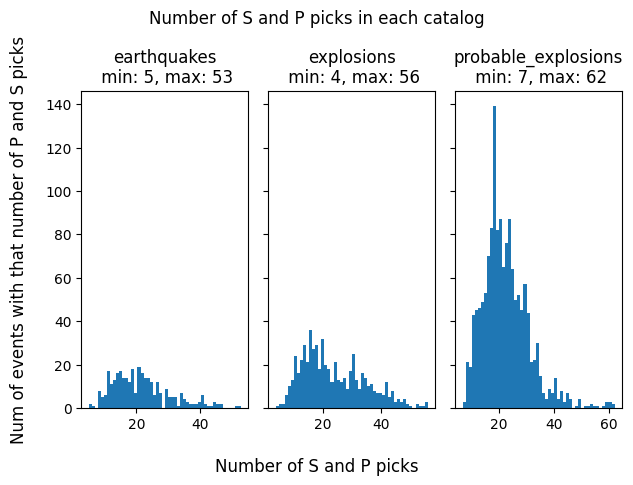

In [12]:
fig , axes = plt.subplots(1, len(catalogs), sharey=True)

for i, (catalog_name, catalog) in enumerate(catalogs.items()):
    picks_dist = []
    for event in catalog:
        num_picks = 0
        for pick in event.picks:
            if pick.phase_hint and pick.phase_hint.startswith(("P", "S")):
                num_picks += 1
        picks_dist.append(num_picks)

    axes[i].hist(picks_dist, bins=50)
    axes[i].set_title(f"{catalog_name}\n min: {min(picks_dist)}, max: {max(picks_dist)}")
fig.supylabel("Num of events with that number of P and S picks")
fig.supxlabel("Number of S and P picks")
fig.suptitle("Number of S and P picks in each catalog")
plt.tight_layout()

### Generate interactive map
Generate interactive map to view seismic event locations, using data from the catalog files (quakeML files)

In [9]:
map_df = pd.DataFrame()

# Extract data to put into interactive map
for event_type, catalog in catalogs.items():
    for event in catalog.events:

        # Extract event origin (long, lat) coordinates
        origin = event.preferred_origin() if event.preferred_origin() else (event.origins[0] if event.origins else None)
        geometry = Point(origin.longitude, origin.latitude) if event.origins else None
        coords = (origin.longitude, origin.latitude) if event.origins else None
        
        magnitude = event.preferred_magnitude().mag if event.preferred_magnitude() else (event.magnitudes[0] if event.magnitudes else -1)

        row_df = pd.DataFrame([{"geometry": geometry, "(lat,long)": coords, "magnitude": magnitude, "event type": event_type}])
        
        map_df = pd.concat([map_df, row_df])

gdf = gpd.GeoDataFrame(data=map_df, geometry="geometry", crs='epsg:4326')
map = gdf.explore(column="event type", popup=True, cmap=["green", "red", "gray"]) # Generate map
map.save("events_map.html") # Export map to html

# Opening miniSEED files
miniSEED files contain earthquake waveforms. 

A data stream is identified by a XX.XXXXX.XX.XXX string, which is a concatenation of station ID and stream ID. 

Station ID is in the form NET_STA:
* NET is network code (1-2 chars)
* STA is station code (1-5 chars). 

Stream ID is in the form LOC_B_S_SS
* LOC is location code (2 chars, but left empty if value is 00): used to uniquely identify different streams in a station 
* B_S_SS is chanel code (3 chars): 
  * B is the band code which identifies the general sample rate
  * S is the source code that identifies the instrument type
  * SS is the subsource code that identifies the orientation of the sensor (Z for vertical, N for north-south, E for east-west).

[source 1](https://docs.fdsn.org/projects/seedlink/en/latest/protocol.html#station-id-and-stream-id:~:text=RFC7159%5D%20format.-,Station%20ID%20and%20stream%20ID,band%20code%2C%20S%20is%20source%20code%20and%20SS%20is%20subsource%20code.,-Station%20ID%20and), [source 2](https://seismology.resif.fr/type-of-data/#:~:text=miniSEED%20data%20is%C2%A0%20identified%20by%20standardized%20codes%20for%20networks%20(groups%20of%20stations)%2C%20stations%20(groups%20of%20channels)%2C%20location%20and%20channels.%20This%20information%20is%20present%20in%20the%20file%20header.), [Data channel search tool](https://ds.iris.edu/ds/nodes/dmc/tools/data_channels/#HHZ), [GEOFON GFZ FDSWS DatasSelect Web Service](http://geofon.gfz-potsdam.de/fdsnws/dataselect/1/) for downloading mseed files to try.

3 Trace(s) in Stream:
HE.HEF..HHZ | 2025-10-06T23:59:56.210000Z - 2025-10-08T00:00:03.460000Z | 100.0 Hz, 8640726 samples
HE.HEF..HHN | 2025-10-06T23:59:59.860000Z - 2025-10-08T00:00:01.750000Z | 100.0 Hz, 8640190 samples
HE.HEF..HHE | 2025-10-06T23:59:58.630000Z - 2025-10-08T00:00:01.680000Z | 100.0 Hz, 8640306 samples


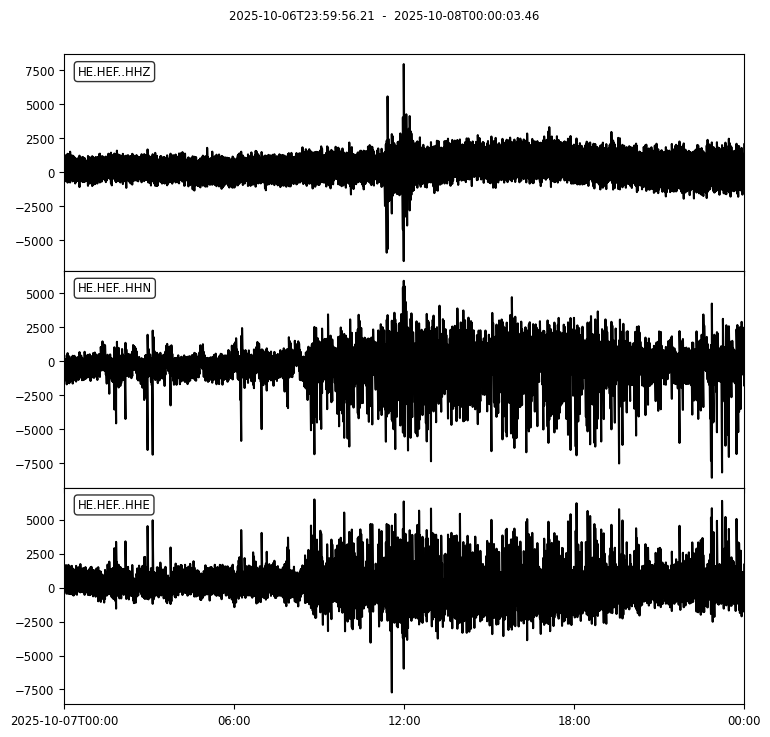

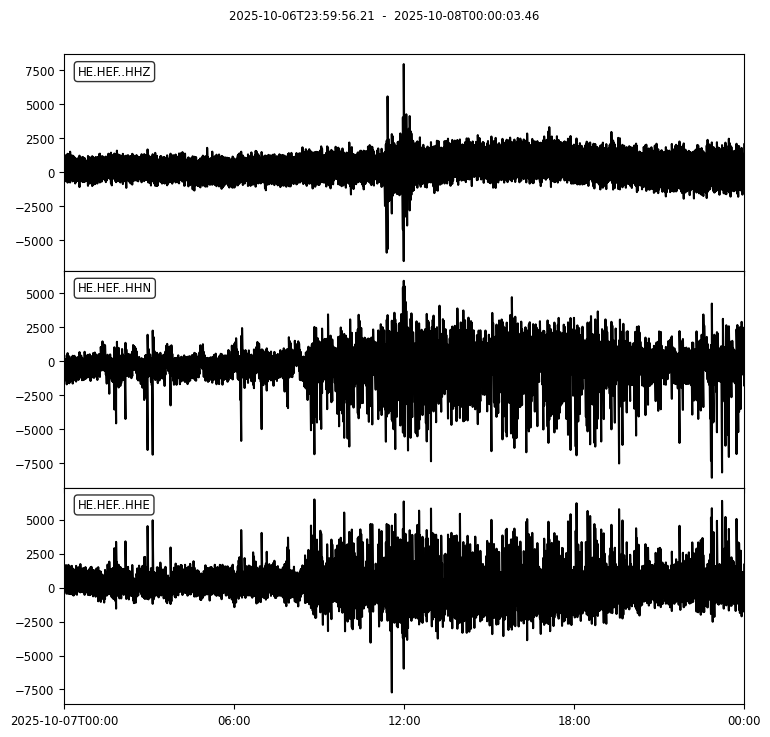

In [ ]:
mseed_filename = "fdsnws.mseed" # download from GFZ or any mseed file provider
stream = obspy.read(data_dir / mseed_filename)
print(stream)
stream.plot()